# DataDriven_Soccer_Scouting

In [21]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras import layers, models
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import time
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "nbformat"])

import warnings
warnings.filterwarnings("ignore")

start_time = time.time()

## Introduction and EDA

In [22]:
df = pd.read_csv("merged_data.csv")
# Convert 'season' to a more readable format (e.g., '2020 - 2021')
df['season'] = df['season'].astype(str).str.zfill(4)
df['season'] = "20" + df['season'].str[:2] + " - 20" + df['season'].str[2:]

# Keep "Position" column instead of "pos"
df.drop(columns=['pos'], inplace=True)
df = df.rename(columns={'Position': 'pos'})

display(df.head())
print('\nRows: {}, Columns: {}'.format(df.shape[0], df.shape[1]))

,league,season,team,player,nation,age,born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,...,Touches_Att Pen,Touches_Def 3rd,Touches_Def Pen,Touches_Live,Touches_Mid 3rd,Touches_Touches,Height,Weight,Preferred foot,pos
0,ENG-Premier League,2024 - 2025,Arsenal,Ben White,ENG,26,1997,17,13,1198,...,28,214,55,813,367,813,NaN,NaN,NaN,NaN
1,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,22,2001,25,20,1729,...,162,57,6,978,216,979,178.0,65.0,Left,RW
2,ENG-Premier League,2024 - 2025,Arsenal,David Raya,ESP,28,1995,38,38,3420,...,0,1388,880,1480,92,1480,183.0,75.0,Right,GK
3,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,25,1999,35,33,2825,...,81,325,82,1948,909,1948,185.0,80.0,Right,CDM
4,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Magalhães,BRA,26,1997,28,28,2363,...,40,672,189,1873,985,1873,NaN,NaN,NaN,NaN



Rows: 4807, Columns: 117


In [23]:
# Removing rows with null values and Goalkeepers (GK)
not_null_df = df.dropna()
not_null_df = not_null_df[not_null_df['pos'] != 'GK']
print('data without null and GKs\n- rows: {} \n- columns: {}'.format(not_null_df.shape[0], not_null_df.shape[1]))
df_backup = df.copy()
df = not_null_df.copy()

data without null and GKs
- rows: 3392 
- columns: 117


In [24]:
# Select all not numeric columns
not_numeric_cols = df.select_dtypes(exclude=[np.number]).columns
display(df[not_numeric_cols].head())

,league,season,team,player,nation,Preferred foot,pos
1,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,Left,RW
3,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,Right,CDM
5,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Martinelli,BRA,Right,LW
6,ENG-Premier League,2024 - 2025,Arsenal,Jakub Kiwior,POL,Left,CB
7,ENG-Premier League,2024 - 2025,Arsenal,Jurriën Timber,NED,Right,RB


In [25]:
# Rename 'Preferred foot' to 'preferred_foot' for consistency
df.rename(columns={'Preferred foot': 'preferred_foot'}, inplace=True)

# Convert preferred_foot to binary (1 for 'Right', 0 for 'Left')
df['preferred_foot_binary'] = df['preferred_foot'].map({'Right': 1, 'Left': 0})

# Identify info columns and create a separate DataFrame for them
info_columns = ['league', 'season', 'team', 'player', 'nation', 'pos', 'born', 'age', 'preferred_foot']
df_info = df[[col for col in df.columns if col.lower() in info_columns]].copy()
numeric_features = df.select_dtypes(include=[np.number]).columns
features = [col for col in numeric_features if col.lower() not in info_columns]

X = df[features].copy()

print(f"Matrix 'X' shape: {X.shape[0]} players x {X.shape[1]} statistics")

X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)

scaler = StandardScaler()

# FIT (impara media e varianza) e TRANSFORM (applica) SOLO sul train
X_train_scaled = scaler.fit_transform(X_train)

# SOLO TRANSFORM sul validation, usando le regole imparate sopra
X_val_scaled = scaler.transform(X_val)

# IMPORTANT: Save the original features list (before it gets modified in KMeans section)
# Why? The KMeans section will remove "noisy" columns (Playing Time, Penalties, etc.) 
# to focus on tactical style rather than volume/exposure. However, for Anomaly Detection,
# we need the full feature space to show players' complete profiles with deviations.
# This way:
# - X_scaled keeps all 109 features (used for anomalies with full context)
# - features_original preserves the full feature names for indexing
# - KMeans will use a cleaned version to avoid volume-based clustering
features_original = features.copy()


Matrix 'X' shape: 3392 players x 109 statistics


## Similarity Search

### PCA - BOSCA

In [26]:
# ----------------------------------------------
# NON RIMUOVERE QUESTA CELLA
# ----------------------------------------------
df_info_reset = df_info.reset_index(drop=True)
df_info_reset

,league,season,team,player,nation,age,born,preferred_foot,pos
0,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,22,2001,Left,RW
1,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,25,1999,Right,CDM
2,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Martinelli,BRA,23,2001,Right,LW
3,ENG-Premier League,2024 - 2025,Arsenal,Jakub Kiwior,POL,24,2000,Left,CB
4,ENG-Premier League,2024 - 2025,Arsenal,Jurriën Timber,NED,23,2001,Right,RB
...,...,...,...,...,...,...,...,...,...
3387,ITA-Serie A,2022 - 2023,Udinese,Lazar Samardzic,SRB,20,2002,Left,CM
3388,ITA-Serie A,2022 - 2023,Udinese,Nehuén Pérez,ARG,22,2000,Right,CB
3389,ITA-Serie A,2022 - 2023,Udinese,Roberto Pereyra,ARG,31,1991,Right,CM
3390,ITA-Serie A,2022 - 2023,Udinese,Rodrigo Becão,BRA,26,1996,Right,CB


Total features: 109
Explained variance by first 10 components: [0.31286314 0.55278969 0.63046851 0.67692586 0.71026894 0.74087428
 0.76627959 0.78993189 0.80798731 0.82346095]
Variance explained by first 20 components: 0.9184
Components needed for 95% variance: 27
Components needed for 90% variance: 18


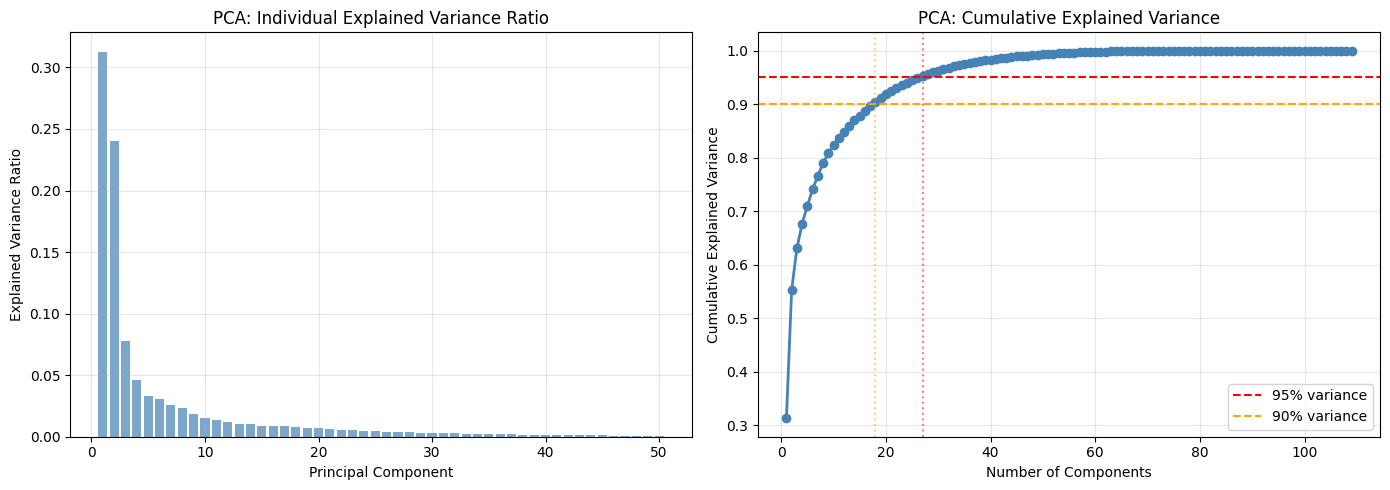

In [27]:
# FONDAMENTALE: Usa X_train_scaled, NON l'intero dataset X_scaled!
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Estrai la varianza spiegata
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"Total features: {X_train_scaled.shape[1]}")
print(f"Explained variance by first 10 components: {cumulative_variance[:10]}")
print(f"Variance explained by first 20 components: {cumulative_variance[19] if len(cumulative_variance) > 19 else cumulative_variance[-1]:.4f}")

# Trova il numero ottimale di componenti (95% della varianza)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components_95}")

# Trova il numero ottimale di componenti (90% della varianza)
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Components needed for 90% variance: {n_components_90}")

# Visualizzazione della varianza spiegata
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Varianza spiegata individuale
# Nota: ho aggiunto un controllo sulla lunghezza di explained_variance per evitare errori
# se hai meno di 50 feature.
max_features_to_plot = min(50, len(explained_variance))
axes[0].bar(range(1, max_features_to_plot + 1), explained_variance[:max_features_to_plot], alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA: Individual Explained Variance Ratio')
axes[0].grid(alpha=0.3)

# Grafico 2: Varianza spiegata cumulativa
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o-', color='steelblue', linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% variance')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% variance')
axes[1].axvline(x=n_components_95, color='r', linestyle=':', alpha=0.5)
axes[1].axvline(x=n_components_90, color='orange', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('PCA: Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

First conclusion: Data is highly reducible: from 109 variables you can reduce to about 20–30 without losing much information.

In [28]:
# Instanzia la PCA finale con il numero che hai deciso guardando il grafico
pca_final = PCA(n_components=n_components_95) # o 18, o 0.95

# Fit e Transform SOLO sul training set
X_train_pca = pca_final.fit_transform(X_train_scaled)

# SOLO Transform sul validation set
X_val_pca = pca_final.transform(X_val_scaled)

### Deep Autoencoder - MURA

#### Relu

--- Building Deep Autoencoder (TensorFlow/Keras) ---

Training in progress...
Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.2747 - val_loss: 0.1736
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1517 - val_loss: 0.1376
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1276 - val_loss: 0.1224
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1147 - val_loss: 0.1104
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1037 - val_loss: 0.1018
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0957 - val_loss: 0.0964
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0899 - val_loss: 0.0915
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0862 - val_loss: 0.0879
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0834 - val_loss: 0.0857
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0815 - val_loss: 0.0849
Epoch 11/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0799 - v

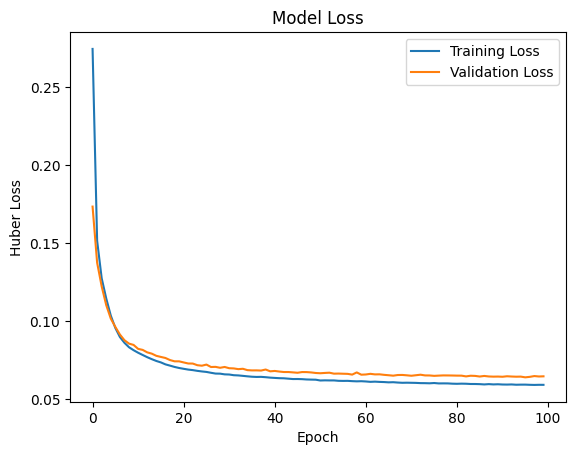


Extracting 10D DNA representation...
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [29]:
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

# L'input deve essere la dimensione dei dati scalati, NON di X_scaled globale
input_dim = X_train_scaled.shape[1]

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (Coerente: usiamo solo ReLU per i layer nascosti)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (Corretto a 'linear' per mappare liberamente le distribuzioni)
bottleneck_layer = layers.Dense(10, activation='linear', name='dna_bottleneck')(encoded)

# DECODER
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Final output (Lineare, per ricostruire i valori originariamente standardizzati)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")

# L'EarlyStopping è obbligatorio per non far memorizzare a memoria il dataset alla rete
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Addestriamo SOLO sul train set e validiamo sul validation set
history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_scaled, X_val_scaled), # Validation esplicito
    callbacks=[early_stop],
    verbose=1
)
print("Training completed!")

# Tracciamo entrambe le curve per verificare l'assenza di overfitting
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.legend()
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

# Ora separiamo l'encoder dal resto della rete
encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)

# IMPORTANTE: Se lo scopo ora è estrarre le statistiche dell'INTERO database per 
# le tue dashboard o ricerche di similarità, devi prima trasformare l'intero X originale.
# X_all_scaled = scaler.transform(X) # <-- NOTA: Usa SOLO transform, lo scaler è quello fittato sul train!

X_all_scaled = scaler.transform(X)
bottleneck_all = encoder.predict(X_all_scaled)

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae = pd.DataFrame(bottleneck_all, columns=ae_columns)

# Assicurati che df_info_reset (che immagino contenga nomi e ID dei giocatori) 
# sia allineato per riga all'intero dataset X.
df_latent_ae_relu = pd.concat([df_info_reset, df_ae], axis=1)

#### Tanh - to train

--- Building Deep Autoencoder (TensorFlow/Keras) ---

Training in progress...
Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.2418 - val_loss: 0.1692
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1534 - val_loss: 0.1395
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1287 - val_loss: 0.1209
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1138 - val_loss: 0.1113
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1061 - val_loss: 0.1047
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1012 - val_loss: 0.1010
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0983 - val_loss: 0.0988
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0954 - val_loss: 0.0970
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0936 - val_loss: 0.0952
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0922 - val_loss: 0.0943
Epoch 11/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0909 -

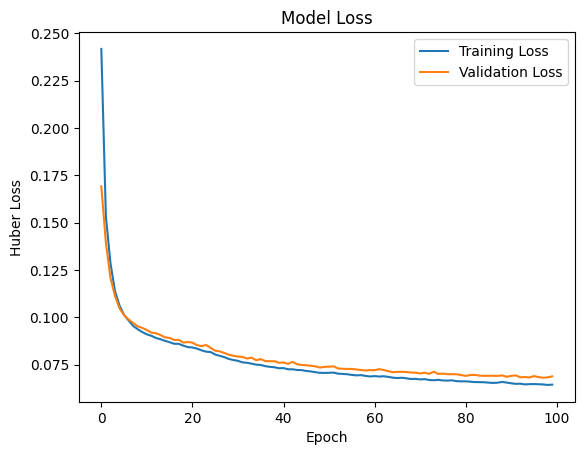


Extracting 10D DNA representation...
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [30]:
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

# L'input deve essere la dimensione dei dati scalati, NON di X_scaled globale
input_dim = X_train_scaled.shape[1]

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (Coerente: usiamo solo ReLU per i layer nascosti)
encoded = layers.Dense(64, activation='tanh')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (Corretto a 'linear' per mappare liberamente le distribuzioni)
bottleneck_layer = layers.Dense(10, activation='linear', name='dna_bottleneck')(encoded)

# DECODER
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='tanh')(decoded)

# Final output (Lineare, per ricostruire i valori originariamente standardizzati)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")

# L'EarlyStopping è obbligatorio per non far memorizzare a memoria il dataset alla rete
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Addestriamo SOLO sul train set e validiamo sul validation set
history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_scaled, X_val_scaled), # Validation esplicito
    callbacks=[early_stop],
    verbose=1
)
print("Training completed!")

# Tracciamo entrambe le curve per verificare l'assenza di overfitting
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.legend()
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

# Ora separiamo l'encoder dal resto della rete
encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)

# IMPORTANTE: Se lo scopo ora è estrarre le statistiche dell'INTERO database per 
# le tue dashboard o ricerche di similarità, devi prima trasformare l'intero X originale.
# X_all_scaled = scaler.transform(X) # <-- NOTA: Usa SOLO transform, lo scaler è quello fittato sul train!

X_all_scaled = scaler.transform(X)
bottleneck_all = encoder.predict(X_all_scaled)

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae = pd.DataFrame(bottleneck_all, columns=ae_columns)

# Assicurati che df_info_reset (che immagino contenga nomi e ID dei giocatori) 
# sia allineato per riga all'intero dataset X.
df_latent_ae_tanh = pd.concat([df_info_reset, df_ae], axis=1)

#### ReLU with dropout

--- Building Deep Autoencoder with Dropout ---

Training in progress...
Epoch 1/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.2811 - val_loss: 0.1791
Epoch 2/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1804 - val_loss: 0.1520
Epoch 3/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1583 - val_loss: 0.1388
Epoch 4/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1473 - val_loss: 0.1301
Epoch 5/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1408 - val_loss: 0.1256
Epoch 6/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1363 - val_loss: 0.1207
Epoch 7/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1317 - val_loss: 0.1185
Epoch 8/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1290 - val_loss: 0.1141
Epoch 9/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1257 - val_loss: 0.1105
Epoch 10/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1241 - val_loss: 0.1099
Epoch 11/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1205 - va

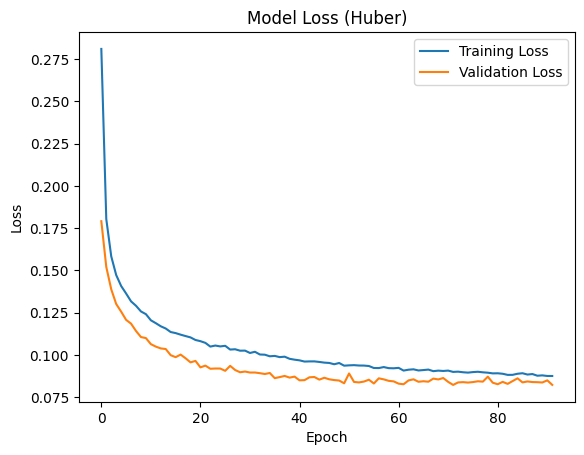


Extracting 10D DNA representation...
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [31]:
print("--- Building Deep Autoencoder with Dropout ---")

# 1. L'input dim DEVE venire dal training set pulito
input_dim = X_train_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU compression + Dropout)
encoded = layers.Dense(128, activation='relu')(input_layer)
encoded = layers.Dropout(0.2)(encoded) # Ottimo qui, forza la rete a cercare percorsi alternativi
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (Corretto a LINEARE: vitale per mantenere lo spazio continuo)
bottleneck_layer = layers.Dense(10, activation='linear', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction + Dropout simmetrico)
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(128, activation='relu')(decoded)

# Final output (Lineare, per ricostruire i valori originariamente standardizzati)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")

# EARLY STOPPING: Assolutamente obbligatorio se metti 500 epoche.
# Si fermerà da solo quando la validation loss smette di scendere per 20 epoche.
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# FIT CORRETTO: Usa X_train_scaled e passa esplicitamente la validazione
history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=500, 
    batch_size=32,
    validation_data=(X_val_scaled, X_val_scaled),
    callbacks=[early_stop],
    verbose=1
)
print("Training completed!")

# Traccia entrambe le curve per capire cosa sta succedendo
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (Huber)' )
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)

# Per estrarre le statistiche finali dell'intero database, devi scalare l'intero X 
# usando il transform dello scaler fittato SOLO sul train (come spiegato nei passaggi precedenti)
X_all_scaled = scaler.transform(X) 
bottleneck_all = encoder.predict(X_all_scaled)

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_relu_dropout = pd.DataFrame(bottleneck_all, columns=ae_columns)

# Allinea con il dataframe informativo
df_latent_ae_relu_dropout = pd.concat([df_info_reset, df_ae_relu_dropout], axis=1)

#### Tanh with dropout - to train

--- Building Deep Autoencoder with Dropout ---

Training in progress...
Epoch 1/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.2257 - val_loss: 0.1538
Epoch 2/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1570 - val_loss: 0.1305
Epoch 3/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1394 - val_loss: 0.1185
Epoch 4/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1311 - val_loss: 0.1138
Epoch 5/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1261 - val_loss: 0.1095
Epoch 6/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1215 - val_loss: 0.1056
Epoch 7/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1180 - val_loss: 0.1032
Epoch 8/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1163 - val_loss: 0.1010
Epoch 9/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1137 - val_loss: 0.0991
Epoch 10/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1122 - val_loss: 0.0981
Epoch 11/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1114 - val_l

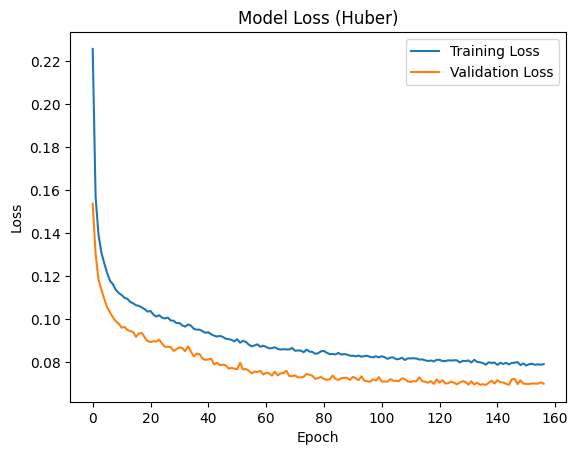


Extracting 10D DNA representation...
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [32]:
print("--- Building Deep Autoencoder with Dropout ---")

# 1. L'input dim DEVE venire dal training set pulito
input_dim = X_train_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU compression + Dropout)
encoded = layers.Dense(128, activation='tanh')(input_layer)
encoded = layers.Dropout(0.2)(encoded) # Ottimo qui, forza la rete a cercare percorsi alternativi
encoded = layers.Dense(64, activation='tanh')(encoded)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (Corretto a LINEARE: vitale per mantenere lo spazio continuo)
bottleneck_layer = layers.Dense(10, activation='linear', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction + Dropout simmetrico)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='tanh')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(128, activation='tanh')(decoded)

# Final output (Lineare, per ricostruire i valori originariamente standardizzati)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")

# EARLY STOPPING: Assolutamente obbligatorio se metti 500 epoche.
# Si fermerà da solo quando la validation loss smette di scendere per 20 epoche.
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# FIT CORRETTO: Usa X_train_scaled e passa esplicitamente la validazione
history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=500, 
    batch_size=32,
    validation_data=(X_val_scaled, X_val_scaled),
    callbacks=[early_stop],
    verbose=1
)
print("Training completed!")

# Traccia entrambe le curve per capire cosa sta succedendo
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (Huber)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)

# Per estrarre le statistiche finali dell'intero database, devi scalare l'intero X 
# usando il transform dello scaler fittato SOLO sul train (come spiegato nei passaggi precedenti)
X_all_scaled = scaler.transform(X) 
bottleneck_all = encoder.predict(X_all_scaled)

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_tanh_dropout = pd.DataFrame(bottleneck_all, columns=ae_columns)

# Allinea con il dataframe informativo
df_latent_ae_tanh_dropout = pd.concat([df_info_reset, df_ae_tanh_dropout], axis=1)

#### Testing Autoencoder

##### Similarity Functions

In [33]:
def find_similar_ae(player_name, player_season, latent_df, top_n=5, max_age=None, season_filter=None, same_position=False, same_league=False, same_preferred_foot=False):
    # Find player index by name and season
    mask_target = (
        (latent_df['player'].str.lower() == player_name.lower())
        & (latent_df['season'] == player_season)
    )
    player_idx = latent_df[mask_target].index

    if len(player_idx) == 0:
        return "Player not found in the database."

    idx = player_idx[0]
    real_player = latent_df.loc[idx, 'player']
    real_team = latent_df.loc[idx, 'team']
    season = latent_df.loc[idx, 'season']
    role = latent_df.loc[idx, 'pos']

    print(f"\n[AUTOENCODER] Searching similar players for: {real_player} ({real_team} - {season})")

    # Extract target player's 10 latent values
    player_vector = latent_df.loc[idx, ae_columns].values.reshape(1, -1)
    # Extract all players' latent values
    all_vectors = latent_df[ae_columns].values

    # Compute cosine similarity
    similarity = cosine_similarity(player_vector, all_vectors)[0]

    # Assign scores
    latent_df_temp = latent_df.copy()
    latent_df_temp['Similarity_Score'] = similarity

    # Exclude target player from results
    latent_df_temp = latent_df_temp.drop(index=idx)

    # Optional age filter
    if max_age is not None:
        latent_df_temp = latent_df_temp[latent_df_temp['age'] <= max_age]

    # Optional season filter
    if season_filter is not None:
        latent_df_temp = latent_df_temp[latent_df_temp['season'] == season_filter]

    # Optional position filter
    if same_position:
        latent_df_temp = latent_df_temp[latent_df_temp['pos'] == role]

    # Optional league filter
    if same_league:
        latent_df_temp = latent_df_temp[latent_df_temp['league'] == latent_df.loc[idx, 'league']]

    # Optional preferred-foot filter
    if same_preferred_foot:
        latent_df_temp = latent_df_temp[latent_df_temp['preferred_foot'] == latent_df.loc[idx, 'preferred_foot']]

    latent_df_temp = latent_df_temp[latent_df_temp['player'] != player_name]

    # Sort from most similar to least similar
    similar_players = latent_df_temp.sort_values(by='Similarity_Score', ascending=False).head(top_n).copy()

    # Format score as a readable percentage
    similar_players['Match %'] = (similar_players['Similarity_Score'] * 100).round(1).astype(str) + '%'

    output_columns = ['player', 'age', 'team', 'pos', 'league', 'season', 'Match %']
    return similar_players[output_columns]

In [34]:
def find_similar_ensemble(
    player_name,
    player_season,
    latent_df_a=df_latent_ae_tanh_btn,
    latent_df_b=df_latent_ae_tanh,
    top_n=5,
    max_age=None,
    season_filter=None,
    same_position=False,
    same_league=False
):
    # Target player
    mask_target = (
        (latent_df_a['player'].str.lower() == player_name.lower())
        & (latent_df_a['season'] == player_season)
    )
    player_idx = latent_df_a[mask_target].index

    if len(player_idx) == 0:
        return "Player not found in the database."

    idx = player_idx[0]
    real_player = latent_df_a.loc[idx, 'player']
    real_team = latent_df_a.loc[idx, 'team']
    season = latent_df_a.loc[idx, 'season']
    role = latent_df_a.loc[idx, 'pos']
    league = latent_df_a.loc[idx, 'league']

    print(f"\n[ENSEMBLE] Searching similar players for: {real_player} ({real_team} - {season})")

    # Average cosine similarity from the three latent spaces
    vector_a = latent_df_a.loc[idx, ae_columns].values.reshape(1, -1)
    vector_b = latent_df_b.loc[idx, ae_columns].values.reshape(1, -1)
    sim_a = cosine_similarity(vector_a, latent_df_a[ae_columns].values)[0]
    sim_b = cosine_similarity(vector_b, latent_df_b[ae_columns].values)[0]
    sim_ensemble = (sim_a + sim_b) / 2

    df_temp = latent_df_a.copy()
    df_temp['Similarity_Score'] = sim_ensemble
    df_temp = df_temp.drop(index=idx)

    if max_age is not None:
        df_temp = df_temp[df_temp['age'] <= max_age]

    if season_filter is not None:
        df_temp = df_temp[df_temp['season'] == season_filter]

    if same_position:
        df_temp = df_temp[df_temp['pos'] == role]

    if same_league:
        df_temp = df_temp[df_temp['league'] == league]

    df_temp = df_temp[df_temp['player'] != player_name]

    similar_players = df_temp.sort_values(by='Similarity_Score', ascending=False).head(top_n).copy()
    similar_players['Match %'] = (similar_players['Similarity_Score'] * 100).round(1).astype(str) + '%'

    return similar_players[['player', 'age', 'team', 'pos', 'league', 'season', 'Match %']]

##### Testing

###### Single Testing

In [35]:
# Testing the models with a target player and season

target_player = "Riccardo Orsolini"
target_season = "2024 - 2025"
max_age = None

models_to_test = {
    'Relu': df_latent_ae_relu,
    'Tanh': df_latent_ae_tanh,
    'ReLU + Dropout': df_latent_ae_relu_dropout,
    'Tanh + Dropout': df_latent_ae_tanh_dropout,
}

for model_name, model_df in models_to_test.items():
    print(f"\n===== Model: {model_name} =====")
    ae_results = find_similar_ae(
        player_name=target_player,
        player_season=target_season,
        latent_df=model_df,
        top_n=5,
        max_age=max_age,
        season_filter=None,
        same_position=True
    )
    display(ae_results)

print("\n===== Model: Ensemble =====")
ensemble_results = find_similar_ensemble(
    player_name=target_player,
    player_season=target_season,
    top_n=5,
    max_age=max_age,
    season_filter=None,
    same_position=True,
    same_league=False
)
display(ensemble_results)


===== Model: Relu =====

[AUTOENCODER] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
368,Dani Raba,28,Leganés,RM,ESP-La Liga,2024 - 2025,92.1%
1296,Michael Olise,21,Crystal Palace,RM,ENG-Premier League,2023 - 2024,91.8%
2685,Ezequiel Ávila,28,Osasuna,RM,ESP-La Liga,2022 - 2023,90.7%
3003,Karim Adeyemi,20,Dortmund,RM,GER-Bundesliga,2022 - 2023,90.3%
153,Mohamed Salah,32,Liverpool,RM,ENG-Premier League,2024 - 2025,90.0%



===== Model: Tanh =====

[AUTOENCODER] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
2176,Cyril Ngonge,23,Hellas Verona,RM,ITA-Serie A,2023 - 2024,85.3%
1225,Antoine Semenyo,23,Bournemouth,RM,ENG-Premier League,2023 - 2024,84.3%
3017,Jesper Lindstrøm,22,Eint Frankfurt,RM,GER-Bundesliga,2022 - 2023,81.7%
1895,Donyell Malen,24,Dortmund,RM,GER-Bundesliga,2023 - 2024,81.6%
2868,Arnaud Nordin,24,Montpellier,RM,FRA-Ligue 1,2022 - 2023,80.6%



===== Model: ReLU + Dropout =====

[AUTOENCODER] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
153,Mohamed Salah,32,Liverpool,RM,ENG-Premier League,2024 - 2025,88.4%
1895,Donyell Malen,24,Dortmund,RM,GER-Bundesliga,2023 - 2024,87.2%
566,Mason Greenwood,22,Marseille,RM,FRA-Ligue 1,2024 - 2025,87.0%
3042,Dodi Lukebakio,24,Hertha BSC,RM,GER-Bundesliga,2022 - 2023,84.9%
368,Dani Raba,28,Leganés,RM,ESP-La Liga,2024 - 2025,82.8%



===== Model: Tanh + Dropout =====

[AUTOENCODER] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
2685,Ezequiel Ávila,28,Osasuna,RM,ESP-La Liga,2022 - 2023,89.1%
2176,Cyril Ngonge,23,Hellas Verona,RM,ITA-Serie A,2023 - 2024,88.8%
1078,Pedro,37,Lazio,RM,ITA-Serie A,2024 - 2025,88.1%
2080,Václav Černý,25,Wolfsburg,RM,GER-Bundesliga,2023 - 2024,88.0%
115,Harry Wilson,27,Fulham,RM,ENG-Premier League,2024 - 2025,85.5%



===== Model: Ensemble =====

[ENSEMBLE] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
2685,Ezequiel Ávila,28,Osasuna,RM,ESP-La Liga,2022 - 2023,80.2%
2176,Cyril Ngonge,23,Hellas Verona,RM,ITA-Serie A,2023 - 2024,79.5%
3042,Dodi Lukebakio,24,Hertha BSC,RM,GER-Bundesliga,2022 - 2023,77.1%
1895,Donyell Malen,24,Dortmund,RM,GER-Bundesliga,2023 - 2024,75.4%
3017,Jesper Lindstrøm,22,Eint Frankfurt,RM,GER-Bundesliga,2022 - 2023,75.2%


###### Bulk Testing

In [36]:
##%%script echo skipping
# Single table with all results (target player x model)
target = ["Kevin De Bruyne", "Alessandro Bastoni", "Manuel Locatelli", "Andrea Pinamonti", 'Erling Haaland', "Xavi Simons", "Riccardo Orsolini"]
same_position = [False, False, False, False, False, False, False]
max_age = 23

target_same_position = dict(zip(target, same_position))
all_results = []

for player in target:
    for model_name, model_df in models_to_test.items():
        res = find_similar_ae(
            player_name=player,
            player_season=target_season,
            latent_df=model_df,
            top_n=5,
            max_age=max_age,
            season_filter=None,
            same_position=target_same_position[player],
            same_league=False,
            same_preferred_foot=False
        )

        if isinstance(res, pd.DataFrame):
            res = res.copy()
            res["target_player"] = player
            res["target_season"] = target_season
            res["model_used"] = model_name
            res["rank"] = range(1, len(res) + 1)
            all_results.append(res)

    # Add the ensemble result as well
    res_ensemble = find_similar_ensemble(
        player_name=player,
        player_season=target_season,
        top_n=5,
        max_age=max_age,
        season_filter=None,
        same_position=target_same_position[player],
        same_league=False
    )

    if isinstance(res_ensemble, pd.DataFrame):
        res_ensemble = res_ensemble.copy()
        res_ensemble["target_player"] = player
        res_ensemble["target_season"] = target_season
        res_ensemble["model_used"] = "Ensemble"
        res_ensemble["rank"] = range(1, len(res_ensemble) + 1)
        all_results.append(res_ensemble)

# Final grouped DataFrame
grouped_results_table = pd.concat(all_results, ignore_index=True)

# Column order for readability
grouped_results_table = (
    grouped_results_table[
        ["target_player", "target_season", "model_used", "rank", "player", "age", "team", "pos", "league", "season", "Match %"]
    ]
    .sort_values(["target_player", "model_used", "rank"])
    .reset_index(drop=True)
)

display(grouped_results_table)


[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[ENSEMBLE] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Alessandro Bastoni (Inter - 2024 - 2025)

[ENSEMBLE] Searching similar players for: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Manuel Locatelli (Juventus - 2024 - 2025)

[AUTOENCODER

,target_player,target_season,model_used,rank,player,age,team,pos,league,season,Match %
0,Alessandro Bastoni,2024 - 2025,Ensemble,1,Riccardo Calafiori,21,Bologna,LB,ITA-Serie A,2023 - 2024,85.0%
1,Alessandro Bastoni,2024 - 2025,Ensemble,2,Jules Koundé,23,Barcelona,RB,ESP-La Liga,2022 - 2023,84.0%
2,Alessandro Bastoni,2024 - 2025,Ensemble,3,Facundo Medina,23,Lens,CB,FRA-Ligue 1,2022 - 2023,81.3%
3,Alessandro Bastoni,2024 - 2025,Ensemble,4,Matteo Ruggeri,21,Atalanta,LM,ITA-Serie A,2023 - 2024,79.8%
4,Alessandro Bastoni,2024 - 2025,Ensemble,5,Joe Scally,20,Gladbach,RB,GER-Bundesliga,2023 - 2024,78.0%
...,...,...,...,...,...,...,...,...,...,...,...
170,Xavi Simons,2024 - 2025,Tanh + Dropout,1,Phil Foden,22,Manchester City,RW,ENG-Premier League,2022 - 2023,96.0%
171,Xavi Simons,2024 - 2025,Tanh + Dropout,2,Paul Nebel,21,Mainz 05,CAM,GER-Bundesliga,2024 - 2025,87.1%
172,Xavi Simons,2024 - 2025,Tanh + Dropout,3,Matìas Soulé,21,Roma,CAM,ITA-Serie A,2024 - 2025,86.3%
173,Xavi Simons,2024 - 2025,Tanh + Dropout,4,Jadon Sancho,22,Manchester Utd,LW,ENG-Premier League,2022 - 2023,84.8%


In [37]:
grouped_results_table.to_csv("resources\grouped_results_table.csv", index=False)

#### Choice explanation

To maximize accuracy and handle tactical nuances such as hybrid roles and statistical outliers, the final pipeline uses an ensemble of two autoencoders and averages their cosine similarity scores.

* Model A: the specialist (ReLU encoder with tanh bottleneck)
    * Architecture: Standard

            Input -> 64 -> Dropout -> 32 -> 10 -> 32 -> 64 -> Dropout -> Output.

    * Encoder activation: ReLU. This can create sparse intermediate representations and keep the model focused on the strongest signals.
    * Bottleneck activation: tanh. This constrains the 10D latent space to [-1, 1], which is compatible with cosine similarity.
    * Epochs & batch size: 400 epochs, batch size 32.

* Model B: the holistic model (tanh network with dropout)
    * Architecture: Deeper layers to capture highly non-linear and complex tactical relationships.

            Input -> 128 -> Dropout -> 64 -> 32 -> 10 -> 32 -> 64 -> Dropout -> 128 -> Output

    * Activation: tanh throughout. This keeps the latent space bounded and preserves sign information in the compressed representation.
    * Epochs & batch size: 400 epochs, batch size 32.

* Model C: the balancer (tanh pure)
    * Architecture: Standard

            Input -> 64 -> 32 -> 10 -> 32 -> 64 -> Output.

    * Activation: tanh throughout. This ensures all neurons remain active, providing a stable, bounded mapping of the data without induced sparsity.
    * Rationale: A clean, holistic baseline with no dropout. It reads the player's entire statistical profile symmetrically, acting as the stabilizing "judge" to ground the results when the first two specialized models disagree heavily.
    * Epochs & batch size: 200 epochs, batch size 32.

* Training hyperparameters (both models)
    * Loss function: Huber. A robust regression loss that is less sensitive to outliers than plain MSE.
    * Optimizer: Adam.

* Ensemble strategy
    * Implementation: Ensemble_Score = (Score_Model_A + Score_Model_B + Score_Model_C) / 3

    * Rationale: 
        * Model A is highly precise but can be rigid; 
        * Model B is tactically creative but can occasionally drift; 
        * Model C provides a stable baseline. 
        
        Averaging their raw Cosine Similarity scores stabilizes the final output. It boosts players recognized by all three architectures while heavily penalizing "hallucinations" (e.g., when a single model confuses a high-scoring winger with a pure striker).

* **NEXT STEP:**
Add spatial/GPS tracking data (e.g., heatmaps, average pitch positions, distance covered) to better contextualize on-ball events and definitively separate players with similar stats but different positional roles on the pitch.

#### Save csv models

In [40]:
#%%script echo skipping
print("--- Final extraction and saving of vector databases ---")

# Latent column names (the 10 dimensions)
ae_columns = [f'AE_{i+1}' for i in range(10)]

print("Saving Model A...")
df_latent_ae_relu_dropout.to_csv('saved_models/database_dna_a.csv', index=False)

print("Saving Model B...")
df_latent_ae_tanh_dropout.to_csv('saved_models/database_dna_b.csv', index=False)

print("CSV files generated successfully. Ready to be loaded in the web app or used for clustering.")

--- Final extraction and saving of vector databases ---
Saving Model A...
Saving Model B...
CSV files generated successfully. Ready to be loaded in the web app or used for clustering.


## Anomaly Detection

### KMeans clustering: Cluster players and look for minorities into clusters - MURA

#### KMeans algorithm

In [ ]:
X_scaled = scaler.fit_transform(X)
                                
noisy_columns = [
    'Playing Time_MP',      
    'Playing Time_Starts',  
    'Playing Time_Min',      
    'Playing Time_90s', 
    'Playing Time_MP',
    'Playing Time_Starts',
    '90s',                  
    'Performance_PK',       
    'Performance_PKatt',    
    'Standard_PK',            
    'Standard_PKatt'        
]

# Drop the noisy columns from the dataframe
# errors='ignore' ensures the code won't crash if a column was already removed
# Build a DataFrame from the scaled array then drop noisy columns
df_scaled = pd.DataFrame(X_scaled, columns=features, index=X.index)
df_clean = df_scaled.drop(columns=noisy_columns, errors='ignore')

# UPDATE: Sync features list with the cleaned DataFrame columns
features = df_clean.columns.tolist()

NameError: name 'X_scaled' is not defined

In [ ]:
# 2. Normalizzazione L2 (Il trucco per lo Stile di Gioco vs Volume)
X_normalized = normalize(df_clean, norm='l2')

k=20

# 3. K-Means "Blindato"
kmeans = KMeans(
    n_clusters=20,      # O 26, decidi tu
    n_init=50,          # Alta stabilità
    random_state=42     # Riproducibilità
)

cluster_labels = kmeans.fit_predict(X_normalized)

# Add cluster labels to the dataframe delle info (presumo contenga i nomi e i team)
df_clusters = df_info_reset.copy()
df_clusters['cluster'] = cluster_labels

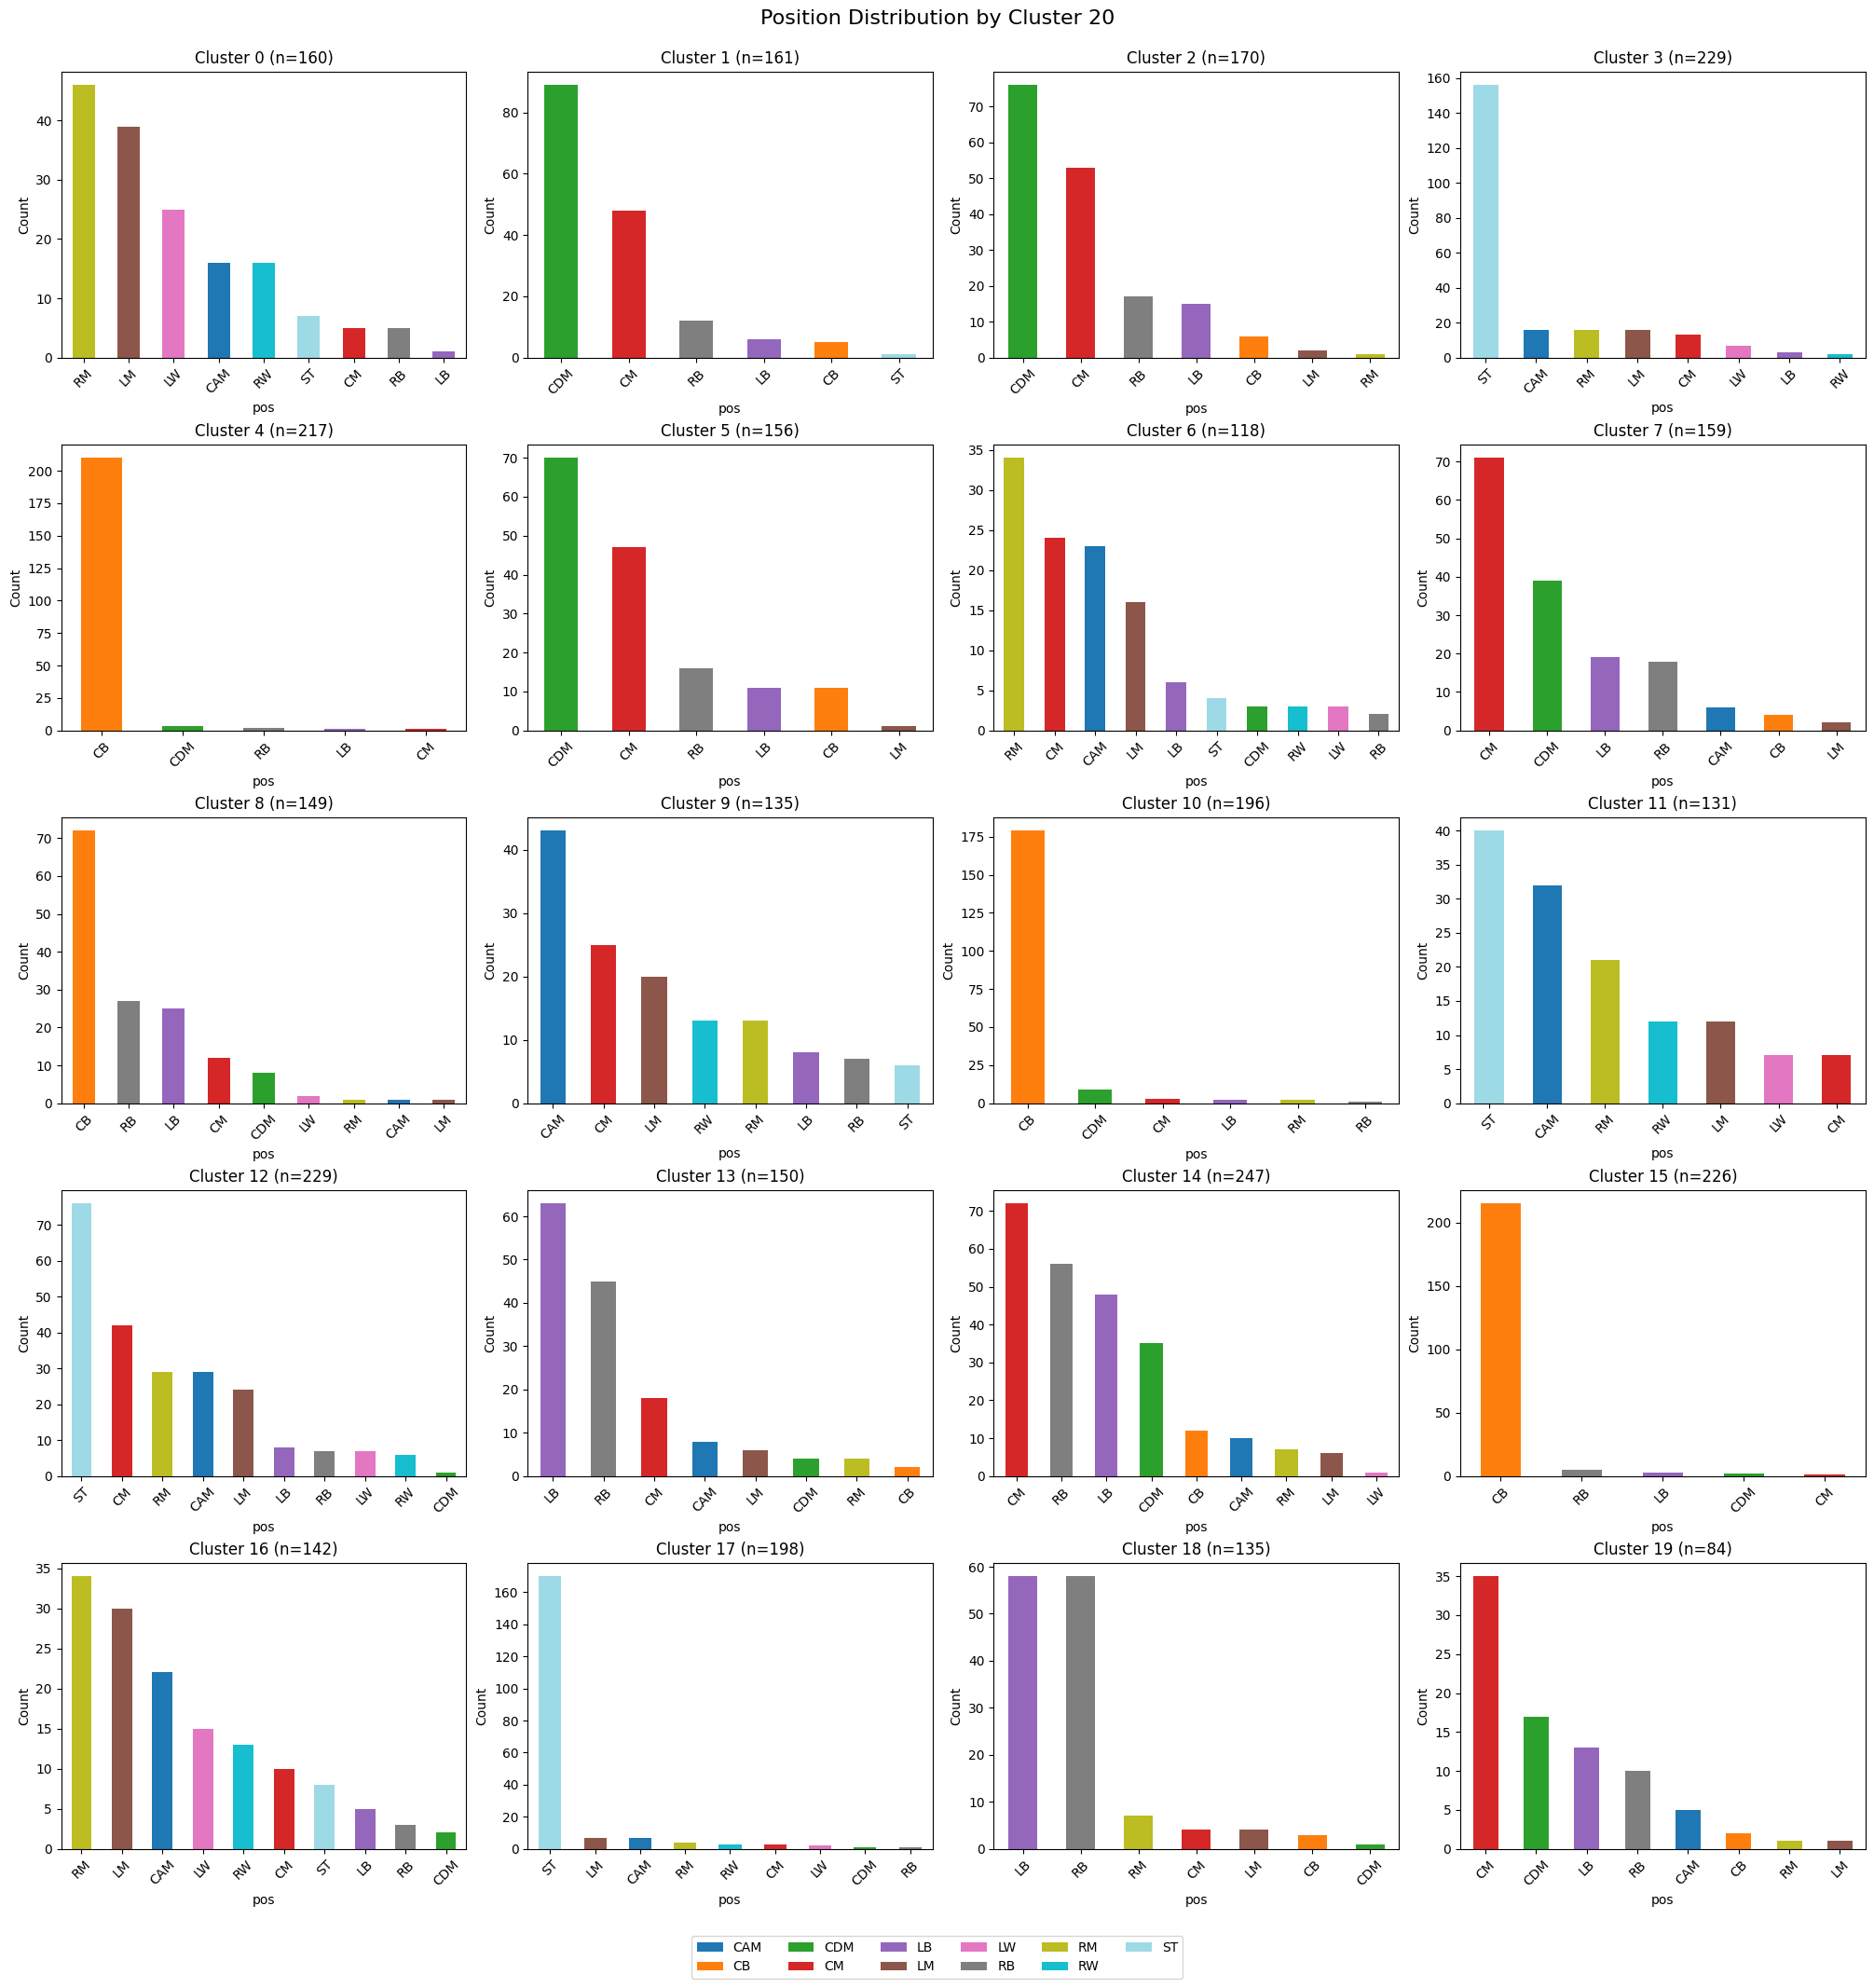

In [ ]:
# ===========================================================================
#   Visualize the distribution of positions within each cluster for KMeans A
# ===========================================================================
cluster_col = "cluster"
pos_col = "pos"

# Create a color mapping for positions
unique_positions = sorted(df_clusters[pos_col].unique())
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_positions)))
color_map = {pos: colors[i] for i, pos in enumerate(unique_positions)}

n_clusters = df_clusters[cluster_col].nunique()
n_cols = 4
n_rows = int(np.ceil(n_clusters / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows), constrained_layout=True)
axes = np.array(axes).ravel()

for cluster_id in sorted(df_clusters[cluster_col].unique()):
    ax = axes[cluster_id]
    cluster_data = df_clusters[df_clusters[cluster_col] == cluster_id]
    pos_counts = cluster_data[pos_col].value_counts()

    # Map colors to each position
    bar_colors = [color_map[pos] for pos in pos_counts.index]
    pos_counts.plot(kind="bar", ax=ax, color=bar_colors)
    ax.set_title(f"Cluster {cluster_id} (n={len(cluster_data)})")
    ax.set_xlabel("pos")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

for j in range(n_clusters, len(axes)):
    fig.delaxes(axes[j])

# Create legend with position colors
legend_elements = [plt.Rectangle((0, 0), 1, 1, facecolor=color_map[pos], label=pos) for pos in unique_positions]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=len(unique_positions)//2 + 1, fontsize=10)

plt.suptitle(f"Position Distribution by Cluster {k}", y=1.02, fontsize=16)
plt.show()

In [ ]:
df_clusters['Dominant_Role_in_Cluster'] = df_clusters.groupby('cluster')['pos'].transform(
    lambda x: x.value_counts().idxmax()
)

#df_clusters.to_csv("resources/df_clusters.csv", index=False)

#### Cluster Analysis

##### Inter-Cluster analysis

In [ ]:
glossary = pd.read_excel("resources\glossary.xlsx")

# Create glossary lookup dictionary
glossary_dict = dict(zip(glossary['KPI'], glossary['Explanation']))

cluster_profile = []

for cluster_id in sorted(df_clusters['cluster'].unique()):
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    
    # 1. Ruolo Dominante
    pos_counts = cluster_data['pos'].value_counts()
    most_freq_pos_str = f"{pos_counts.index[0]} ({pos_counts.iloc[0]}, {(pos_counts.iloc[0]/len(cluster_data)*100):.1f}%)"
    
    # 2. Altri Ruoli
    other_pos_list = [f"{pos} ({count}, {(count/len(cluster_data)*100):.1f}%)" for pos, count in pos_counts.iloc[1:].items()]
    other_pos = ', '.join(other_pos_list)
    
    # 3. Estrazione Feature dal K-Means
    cluster_center = kmeans.cluster_centers_[cluster_id]
    
    # Ordina tutti gli indici dal valore più alto al più basso
    sorted_idx = np.argsort(cluster_center)[::-1]
    
    # Filtra separatamente chi è > 0 (Positivi) e chi è < 0 (Negativi, ordinati dal più basso)
    pos_indices = [i for i in sorted_idx if cluster_center[i] > 0]
    neg_indices = [i for i in sorted_idx[::-1] if cluster_center[i] < 0] 
    
    # Funzione di supporto per estrarre le top K feature (aggiunge "-" se mancano)
    def get_feature_str(indices, k=3, is_positive=True):
        res = []
        for i in indices[:k]:
            val = cluster_center[i]
            sign = "+" if is_positive else ""
            # Inseriamo il nome della feature e il suo valore
            res.append(f"{features[i]} ({sign}{val:.2f})")
            
        # Riempi i vuoti se ci sono meno di 3 feature
        while len(res) < k:
            res.append("-")
        return res

    # Estrai le 3 migliori positive e le 3 peggiori negative
    pos_features = get_feature_str(pos_indices, k=3, is_positive=True)
    neg_features = get_feature_str(neg_indices, k=3, is_positive=False)
    
    # Aggiungiamo tutto al dizionario (che diventerà una riga del DataFrame)
    cluster_profile.append({
        'cluster': cluster_id,
        'player_count': len(cluster_data),
        'dominant_role': most_freq_pos_str,
        'other_positions': other_pos if other_pos else '-',
        'top_pos_1': pos_features[0],
        'top_pos_2': pos_features[1],
        'top_pos_3': pos_features[2],
        'top_neg_1': neg_features[0],
        'top_neg_2': neg_features[1],
        'top_neg_3': neg_features[2]
    })

# Crea il DataFrame finale
df_cluster_profile = pd.DataFrame(cluster_profile)

In [ ]:
scouting_reports = {
    0: "Elite Agility Wingers - Short and light wingers specialized in dribbling and carrying the ball into the opponent's penalty area. They offer zero defensive presence against shots.",
    1: "Shot-Heavy Midfield Anchors - Defensive midfielders who guard the middle third but have zero finishing efficiency. They are known for attempting shots from excessive distances.",
    2: "High-Volume Defensive Grinders - Central midfielders focused exclusively on tackling and contesting the ball. They provide zero offensive production, both actual and expected.",
    3: "Ghost-Poachers - Pure forwards with elite finishing efficiency per 90 minutes, but completely isolated from the build-up. They participate little in active play and have mediocre short passing percentages.",
    4: "Low-Block Wall - Old-school center-backs. They dominate in clearances and blocked shots. They never participate in ball progression and almost never receive the ball in forward positions.",
    5: "Central Metronomes - Playmakers who manage possession in the middle third and distribute the ball toward the final third. They are the heart of the build-up but never personally threaten the goal.",
    6: "High-Risk/Low-Reward Dribblers - Wingers who attempt many dribbles but are often stopped or lose possession. They drastically underperform compared to their expected goals and do not provide depth.",
    7: "Technical Verticalizers - Physically light central midfielders who are fundamental for vertical progression. They break lines with passing but do not have a dangerous shot.",
    8: "Clinical Aerial Threats - Defenders or fullbacks who take very few shots but are lethal when they do, likely on set pieces. They avoid advanced possession.",
    9: "Pure Playmakers - Attacking midfielders focused entirely on chance creation. Low center of gravity players who offer no defensive coverage in their own penalty area.",
    10: "Technical Giants - Tall center-backs with above-average technical cleanliness. They excel in the accuracy of medium passes and have a high success rate in defensive dribbling.",
    11: "Specialized Finishers - Forwards whose only statistical contribution is scoring. They show zero participation in the defensive phase, zero clearances, and zero tackles won.",
    12: "Inefficient Volume Shooters - Players who attempt many shots and shots on target but have very low overall involvement in the game and are often intercepted while on the ball.",
    13: "Traditional Fullbacks - Fullbacks focused on crossing into the area and direct tackling of the ball carrier. They have practically no goal-scoring ambition.",
    14: "Long-Range Shield - Holding midfielders who protect the defense and complete short passes, but in attack limit themselves to speculative shots from outside the area with poor accuracy.",
    15: "First-Phase Specialists - Center-backs who handle the first touches of the build-up in their own third. They never carry the ball forward and do not receive progressive passes.",
    16: "Final-Third Specialists - Wingers who live in the last 30 meters. They provide elite assists and expected assists but completely ignore the defensive and transition phases.",
    17: "Box-Target Strikers - Forwards who constantly position themselves to receive high-quality chances, but are technically limited in passing accuracy.",
    18: "Lockdown Wide Defenders - Stay-back fullbacks. They excel in contests, defensive tackles, and crossing, but have very poor accuracy in long passes.",
    19: "Clinical Midfield Pivots - Midfielders who manage the ball with extreme cleanliness. When they shoot they are very accurate, although they shoot rarely."
}

df_target = df_cluster_profile
nome_colonna_id = 'cluster'

df_target['scouting_report'] = df_target[nome_colonna_id].map(scouting_reports)

display(df_target[[nome_colonna_id, 'dominant_role', 'scouting_report']].head())

#df_target.to_csv(r"resources\df_cluster_profile.csv", index=False)

,cluster,dominant_role,scouting_report
0,0,"RM (46, 28.7%)",Elite Agility Wingers - Short and light winger...
1,1,"CDM (89, 55.3%)",Shot-Heavy Midfield Anchors - Defensive midfie...
2,2,"CDM (76, 44.7%)",High-Volume Defensive Grinders - Central midfi...
3,3,"ST (156, 68.1%)",Ghost-Poachers - Pure forwards with elite fini...
4,4,"CB (210, 96.8%)",Low-Block Wall - Old-school center-backs. They...


In [ ]:
pivot_pos = pd.crosstab(df_clusters['cluster'], df_clusters['pos'])
pivot_norm = pivot_pos.div(pivot_pos.sum(axis=1), axis=0)
pos_corr = pivot_norm.corr()

# Sort the correlation matrix by the specified position order
position_order = ['CB', 'RB', 'LB', 'CDM', 'CM', 'RM', 'LM', 'CAM', 'RW', 'LW', 'ST']
# Filter to keep only positions that exist in the data
position_order = [pos for pos in position_order if pos in pos_corr.columns]
pos_corr = pos_corr.loc[position_order, position_order]

fig = px.imshow(
    pos_corr,
    labels=dict(x="Position", y="Position", color="Correlation"),
    x=pos_corr.columns,
    y=pos_corr.columns,
    color_continuous_scale='RdBu_r',
    zmin=-0.5,
    zmax=1,
    text_auto='.2f',
    aspect='auto',
    title="Tactical Similarity Between Positions Based on Cluster Distribution Correlation"
)

fig.update_layout(
    title_x=0.5,
    width=900,
    height=800,
    xaxis_tickangle=-45
)

fig.show()

##### Intra-Cluster Analysis [Functions]

In [ ]:
def analyze_cluster(cluster_id):

    dominant_pos = df_cluster_profile.loc[cluster_id, "dominant_role"].split(" ")[0]
    
    print("==============================")
    print(f"Cluster {cluster_id} Profile:")
    print("==============================")
    print("Top 5 features: ")
    for col in ['top_pos_1', 'top_pos_2', 'top_pos_3', 'top_neg_1', 'top_neg_2', 'top_neg_3']:
        feature = df_cluster_profile.loc[cluster_id, col]
        print(f"{col}: {feature}")
        # Extract feature name (before the parenthesis)
        if feature != "-":
            feature_name = feature.split(" (")[0]
            if feature_name in glossary_dict:
                print(f"  → {glossary_dict[feature_name][:100]}...")
    print("Most frequent position: ", df_cluster_profile.loc[cluster_id, "dominant_role"])
    print("Other positions: ", df_cluster_profile.loc[cluster_id, "other_positions"])
    print("==============================")
    print("Average profile:")
    print(df_cluster_profile.loc[cluster_id, "scouting_report"])
    print("==============================")
    print(f"Anomalies in Cluster {cluster_id}:")
    display(df_clusters[(df_clusters['cluster'] == cluster_id) & (df_clusters['pos'] != dominant_pos)][['player', 'pos', 'team', 'season']])
    print("==============================")
    
analyze_cluster(18)

Cluster 18 Profile:
Top 5 features: 
top_pos_1: CrsPA (+0.21)
  → Completed crosses into the opponent's penalty area (excluding set pieces)....
top_pos_2: Challenges_Tkl (+0.10)
  → Number of times a player successfully tackled an opponent who was dribbling....
top_pos_3: Tackles_Def 3rd (+0.10)
  → Number of tackles performed in the defensive third of the pitch....
top_neg_1: Long_Cmp% (-0.13)
  → Percentage of long passes successfully completed....
top_neg_2: Standard_Sh/90 (-0.11)
  → Average number of shots taken per 90 minutes....
top_neg_3: Standard_SoT/90 (-0.11)
  → Average number of shots on target per 90 minutes....
Most frequent position:  LB (58, 43.0%)
Other positions:  RB (58, 43.0%), RM (7, 5.2%), CM (4, 3.0%), LM (4, 3.0%), CB (3, 2.2%), CDM (1, 0.7%)
Average profile:
Lockdown Wide Defenders - Stay-back fullbacks. They excel in contests, defensive tackles, and crossing, but have very poor accuracy in long passes.
Anomalies in Cluster 18:


,player,pos,team,season
21,Matty Cash,RB,Aston Villa,2024 - 2025
49,Vitaly Janelt,CM,Brentford,2024 - 2025
96,Ashley Young,RB,Everton,2024 - 2025
230,Djed Spence,RB,Tottenham,2024 - 2025
290,Nahuel Molina,RB,Atlético Madrid,2024 - 2025
...,...,...,...,...
3271,Manuel Lazzari,RB,Lazio,2022 - 2023
3312,Samuele Birindelli,RB,Monza,2022 - 2023
3335,Zeki Çelik,RB,Roma,2022 - 2023
3366,Kelvin Amian,RB,Spezia,2022 - 2023


In [ ]:
def plot_cluster_positions(cluster_id, df_clusters=df_clusters):
    """
    Create a bar plot showing the distribution of positions in a specific cluster
    """
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    pos_counts = cluster_data['pos'].value_counts().reset_index()
    pos_counts.columns = ['Position', 'Count']
    
    unique_positions = sorted(df_clusters['pos'].unique())
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_positions)))
    color_map = {
        pos: f'#{int(colors[i][0]*255):02x}{int(colors[i][1]*255):02x}{int(colors[i][2]*255):02x}'
        for i, pos in enumerate(unique_positions)
    }
    
    fig = px.bar(
        pos_counts,
        x='Position',
        y='Count',
        title=f'Position Distribution in Cluster {cluster_id}',
        labels={'Count': 'Number of Players', 'Position': 'Position'},
        color='Position',
        color_discrete_map=color_map,
        text='Count'
    )
    fig.update_traces(textposition='auto')
    fig.update_layout(title_x=0.5)
    fig.show()

def plot_cluster_league(cluster_id, df_clusters=df_clusters):
    """
    Create a bar plot showing the normalized distribution of leagues in a specific cluster
    (normalized by the total number of players in each league)
    """
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    
    # Count players by league in this cluster
    league_counts_cluster = cluster_data['league'].value_counts().reset_index()
    league_counts_cluster.columns = ['League', 'Count_in_Cluster']
    
    # Count total players by league in the entire dataset
    league_counts_total = df_clusters['league'].value_counts().reset_index()
    league_counts_total.columns = ['League', 'Total_Count']
    
    # Merge and calculate normalized percentage
    league_data = league_counts_cluster.merge(league_counts_total, on='League')
    league_data['Percentage'] = (league_data['Count_in_Cluster'] / league_data['Total_Count'] * 100).round(1)
    
    # Sort by percentage descending
    league_data = league_data.sort_values('Percentage', ascending=False)
    
    # Define league colors with hex codes
    league_colors = {
        'ESP-La Liga': "#FF4B44",
        'ENG-Premier League': '#04F5FF',
        'GER-Bundesliga': "#777777",
        'FRA-Ligue 1': '#CDFB0A',
        'ITA-Serie A': '#0578FF'
    }
    
    fig = px.bar(
        league_data,
        x='League',
        y='Percentage',
        title=f'League Distribution in Cluster {cluster_id} (Normalized by League Size)',
        labels={'Percentage': '% of League Players in Cluster', 'League': 'League'},
        text='Percentage',
        color='League',
        color_discrete_map=league_colors,
        hover_data={'Count_in_Cluster': True, 'Total_Count': True, 'Percentage': ':.1f'}
    )
    
    fig.update_traces(textposition='auto', marker_line_width=0.2, marker_line_color='black')
    fig.update_layout(title_x=0.5, xaxis_tickangle=-45, showlegend=False)
    fig.show()
    
plot_cluster_league(0)

### Autoencoder Reconstruction Error - BOSCA

--- Building Autoencoder per Player Position (sklearn - StandardScaler Optimized) ---

Processing position: RW (68 players)...

Processing position: CDM (360 players)...

Processing position: LW (69 players)...

Processing position: CB (721 players)...

Processing position: RB (292 players)...

Processing position: ST (468 players)...

Processing position: CM (494 players)...

Processing position: LB (295 players)...

Processing position: LM (187 players)...

Processing position: RM (220 players)...

Processing position: CAM (218 players)...

Generating Loss Convergence Plots...


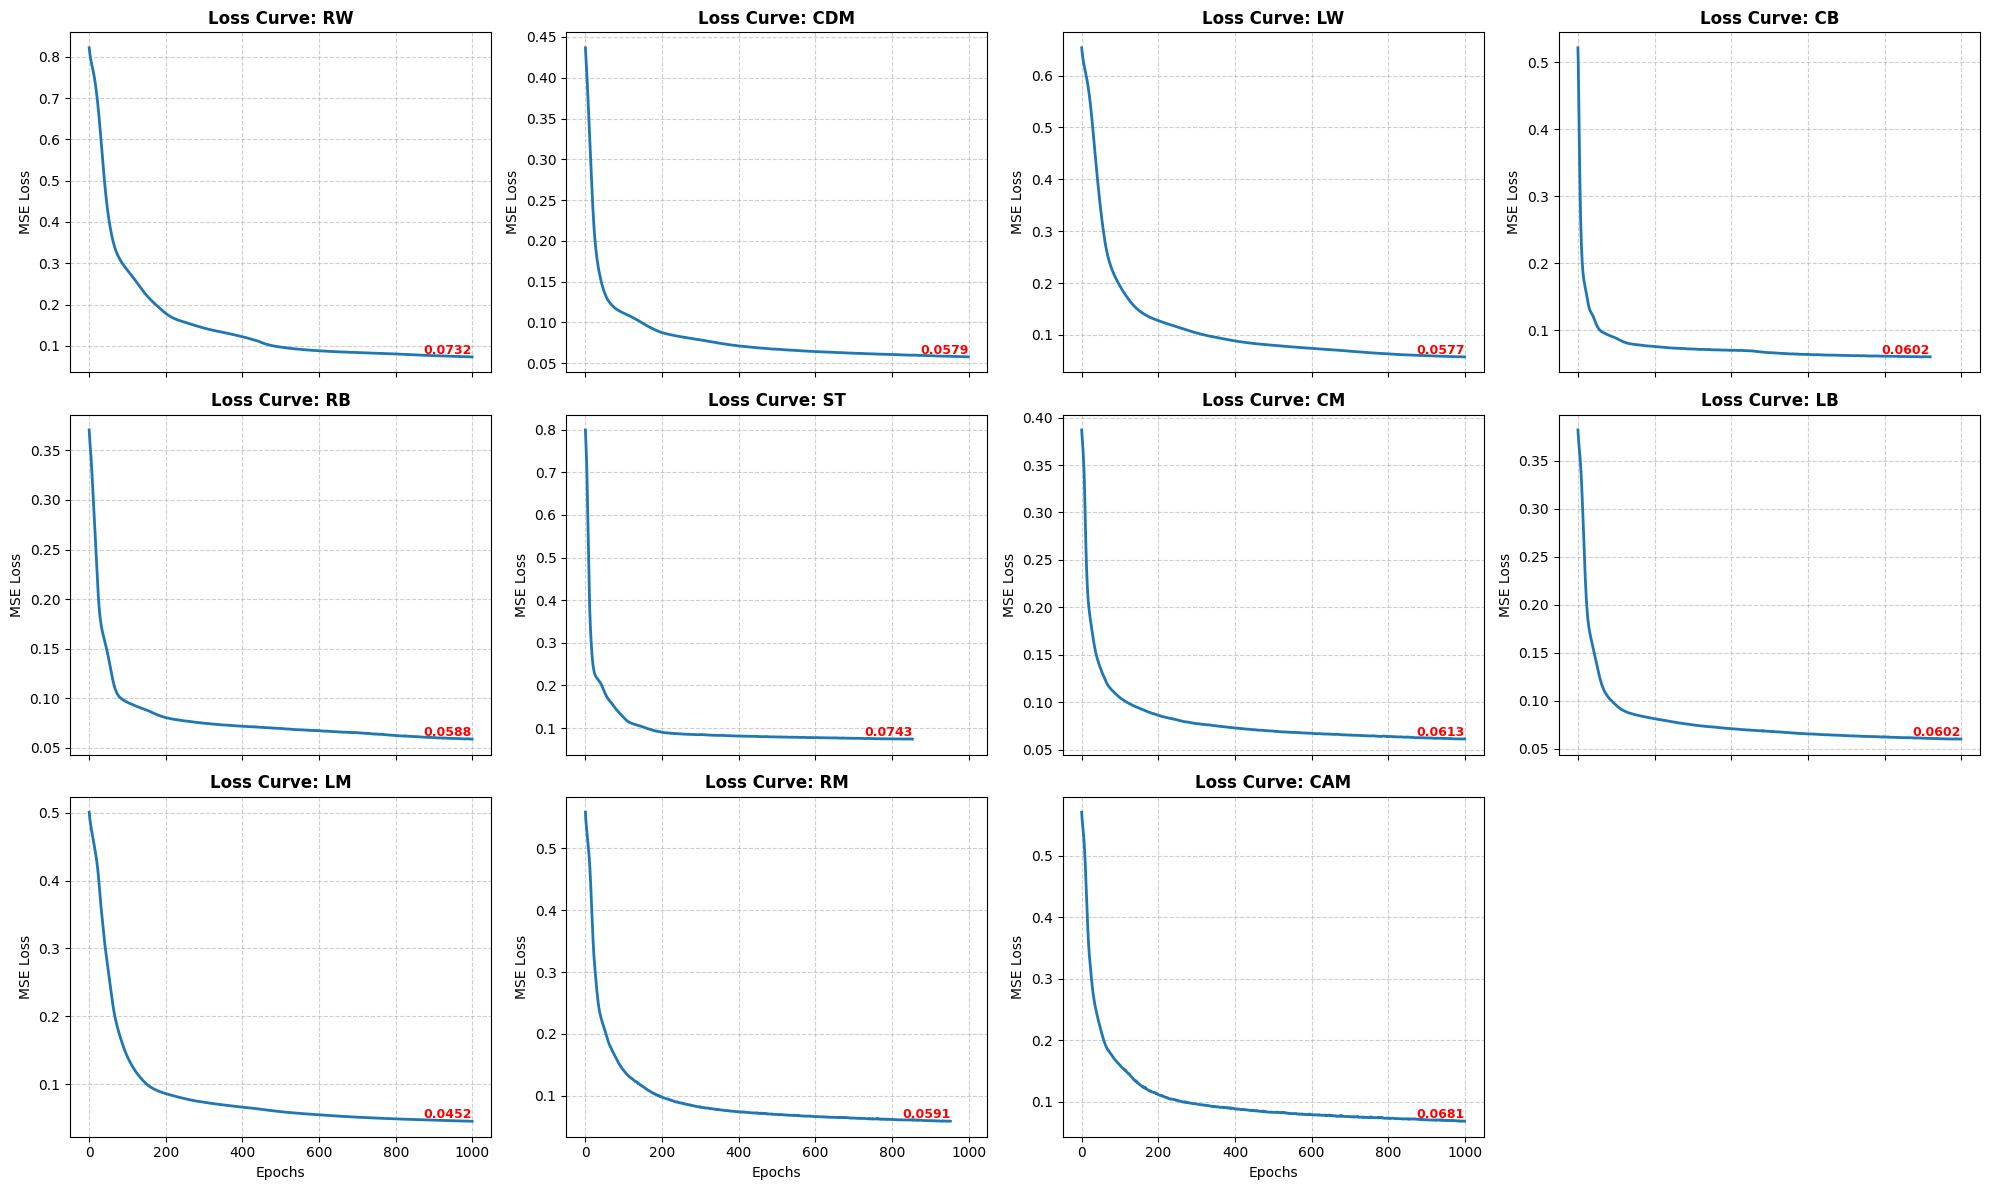


--- All Position-Specific Anomalies (Top 10 overall with Z-Score > 2.5) ---
Total anomalies found: 76


,league,season,team,player,nation,age,born,preferred_foot,pos,raw_reconstruction_error,anomaly_score_z
2008,ESP-La Liga,2024 - 2025,Atlético Madrid,Pablo Barrios,ESP,21,2003,Right,CM,0.395128,7.597095
1091,FRA-Ligue 1,2022 - 2023,Clermont Foot,Alidu Seidu,GHA,22,2000,Right,CB,0.374479,6.351472
2003,ENG-Premier League,2024 - 2025,West Ham,Lucas Paquetá,BRA,26,1997,Left,CM,0.297494,5.114380
1436,ENG-Premier League,2022 - 2023,Southampton,Ainsley Maitland-Niles,ENG,24,1997,Right,RB,0.261989,4.922595
2791,ESP-La Liga,2024 - 2025,Girona,Bryan Gil,ESP,23,2001,Left,LM,0.202322,4.756373
1622,GER-Bundesliga,2024 - 2025,Stuttgart,Nick Woltemade,GER,22,2002,Right,ST,0.369015,4.741241
3226,GER-Bundesliga,2024 - 2025,Leverkusen,Florian Wirtz,GER,21,2003,Right,CAM,0.295205,4.733420
1088,ESP-La Liga,2022 - 2023,Villarreal,Pau Torres,ESP,25,1997,Left,CB,0.303448,4.709700
2709,ESP-La Liga,2022 - 2023,Rayo Vallecano,Fran Garcia,ESP,22,1999,Left,LB,0.256838,4.207687
1604,GER-Bundesliga,2024 - 2025,Gladbach,Tim Kleindienst,GER,28,1995,Left,ST,0.339262,4.160103


In [ ]:
print("--- Building Autoencoder per Player Position (sklearn - StandardScaler Optimized) ---")

unique_positions = df_info_reset['pos'].unique()
all_reconstruction_errors_by_pos = []

# Dizionario per memorizzare le curve di loss di ciascun ruolo per il plot finale
loss_curves_dict = {}

# Soglia minima di sicurezza per evitare l'overfitting da scarsità di dati
MIN_SAMPLES = 40 

for pos_name in unique_positions:
    position_mask = df_info_reset['pos'] == pos_name
    X_scaled_pos = X_scaled[position_mask]
    df_info_pos = df_info_reset[position_mask].copy()
    
    n_samples = X_scaled_pos.shape[0]
    print(f"\nProcessing position: {pos_name} ({n_samples} players)...")
    
    if n_samples < MIN_SAMPLES:
        print(f"  ⚠️ Warning: Too few samples for {pos_name}. Skipping to prevent overfitting.")
        continue

    # Regoliamo l'architettura dinamicamente in base al numero di campioni
    hidden_layers = (64, 32, 10, 32, 64) if n_samples > 150 else (32, 16, 8, 16, 32)

    autoencoder_pos = MLPRegressor(
        hidden_layer_sizes=hidden_layers,
        activation='relu',  
        solver='adam',
        alpha=0.01,                # Regolarizzazione L2 ammorbidita (il giusto freno)
        learning_rate_init=0.001,  # IL FIX: Torniamo al valore di default per passi corti e stabili
        early_stopping=False,      
        tol=1e-5,                  
        n_iter_no_change=20,       # Aspettiamo solo 20 epoche prima di chiudere (evita i rimbalzi)
        max_iter=1000,             
        random_state=42
    )

    # TRAINING
    autoencoder_pos.fit(X_scaled_pos, X_scaled_pos)
    
    # 🌟 SALVATAGGIO DELLA CURVA DI LOSS
    # Salviamo lo storico dell'errore di questa specifica posizione
    loss_curves_dict[pos_name] = autoencoder_pos.loss_curve_

    # RECONSTRUCTION ERROR
    X_reconstructed_pos = autoencoder_pos.predict(X_scaled_pos)
    reconstruction_errors_pos = np.mean((X_scaled_pos - X_reconstructed_pos) ** 2, axis=1)

    df_reconstruction_error_pos = df_info_pos.copy()
    df_reconstruction_error_pos['raw_reconstruction_error'] = reconstruction_errors_pos
    
    # Standardizziamo l'errore all'interno del ruolo (Z-score dell'errore)
    pos_mean = np.mean(reconstruction_errors_pos)
    pos_std = np.std(reconstruction_errors_pos) if np.std(reconstruction_errors_pos) > 0 else 1
    
    df_reconstruction_error_pos['anomaly_score_z'] = (reconstruction_errors_pos - pos_mean) / pos_std
    all_reconstruction_errors_by_pos.append(df_reconstruction_error_pos)

# ==========================================================
# 🌟 GENERAZIONE AUTOMATICA DEL PLOT DELLA LOSS DI RICOSTRUZIONE
# ==========================================================
if loss_curves_dict:
    print("\nGenerating Loss Convergence Plots...")
    num_plots = len(loss_curves_dict)
    
    # Calcoliamo righe e colonne per la griglia dei grafici (massimo 4 colonne)
    cols = min(4, num_plots)
    rows = int(np.ceil(num_plots / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), sharex=True)
    axes = axes.flatten() if num_plots > 1 else [axes]
    
    for i, (pos_name, curve) in enumerate(loss_curves_dict.items()):
        ax = axes[i]
        ax.plot(curve, color='#1f77b4', linewidth=2, label='Training Loss')
        ax.set_title(f"Loss Curve: {pos_name}", fontsize=12, fontweight='bold')
        ax.set_ylabel("MSE Loss")
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Evidenziamo il valore finale raggiunto della loss nell'ultima epoca
        ax.text(len(curve)-1, curve[-1], f"{curve[-1]:.4f}", 
                fontsize=9, va='bottom', ha='right', color='red', weight='bold')
        
    # Nascondiamo i sotto-grafici vuoti se la griglia ha più spazi del necessario
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    # Impostiamo l'etichetta comune per l'asse X in basso
    for ax in axes[-cols:]:
        ax.set_xlabel("Epochs")
        
    plt.tight_layout()
    plt.show()

# FINAL TABLE COMPARISON
if all_reconstruction_errors_by_pos:
    df_all_position_anomalies = pd.concat(all_reconstruction_errors_by_pos, ignore_index=True)
    
    # Il tuo filtro per tenere solo le vere anomalie multivariate (Z-Score > 3)
    df_all_position_anomalies = df_all_position_anomalies[df_all_position_anomalies['anomaly_score_z'] > 2.5]
    
    print(f"\n--- All Position-Specific Anomalies (Top 10 overall with Z-Score > 2.5) ---")
    print(f"Total anomalies found: {len(df_all_position_anomalies)}")
    
    # Ordiniamo per l'anomalia standardizzata (Z-score) decrescente
    display(
        df_all_position_anomalies
        .sort_values(by='anomaly_score_z', ascending=False)
        .head(10)
    )
else:
    print("\nNo models trained due to insufficient data.")

In [ ]:
def get_player_feature_deviations(player_idx, position, X_scaled, df_info_reset, features_original):
    """
    Calculate deviations from position average for a specific player.
    Returns top 3 positive and worst 3 negative deviations as individual formatted strings.
    """
    # Get position average (from standardized data)
    position_mask = df_info_reset['pos'] == position
    position_avg = X_scaled[position_mask].mean(axis=0)
    
    # Get player's standardized profile
    player_profile = X_scaled[player_idx]
    
    # Calculate deviations
    deviations = player_profile - position_avg
    
    # Get top 3 positive and worst 3 negative
    top_3_indices = np.argsort(deviations)[-3:][::-1]  # Sort descending
    worst_3_indices = np.argsort(deviations)[:3]  # Sort ascending
    
    # Format as individual strings with explicit "+" sign for positive deviations
    top_features = [f"{features_original[i]} (+{deviations[i]:.2f})" for i in top_3_indices]
    worst_features = [f"{features_original[i]} ({deviations[i]:.2f})" for i in worst_3_indices]
    
    # Pad with "-" if needed (safety check)
    while len(top_features) < 3:
        top_features.append("-")
    while len(worst_features) < 3:
        worst_features.append("-")
    
    return tuple(top_features + worst_features)

# Apply to the anomalies dataframe
print("Extracting feature deviations for each anomalous player...")

top_1_list = []
top_2_list = []
top_3_list = []
worst_1_list = []
worst_2_list = []
worst_3_list = []

for idx, row in df_all_position_anomalies.iterrows():
    player_name = row['player']
    position = row['pos']
    team_name = row['team']  # Aggiunto il team per evitare ambiguità in caso di omonimi
    
    # Trova l'indice originale associandolo a giocatore, ruolo e squadra per massima sicurezza
    match_mask = (df_info_reset['player'] == player_name) & (df_info_reset['pos'] == position) & (df_info_reset['team'] == team_name)
    
    # Fallback nel caso in cui la squadra differisca per micro-stringhe
    if not match_mask.any():
        match_mask = (df_info_reset['player'] == player_name) & (df_info_reset['pos'] == position)
        
    original_idx = df_info_reset[match_mask].index[0]
    
    # Estrazione delle deviazioni
    top_1, top_2, top_3, worst_1, worst_2, worst_3 = get_player_feature_deviations(
        original_idx, position, X_scaled, df_info_reset, features_original
    )
    
    top_1_list.append(top_1)
    top_2_list.append(top_2)
    top_3_list.append(top_3)
    worst_1_list.append(worst_1)
    worst_2_list.append(worst_2)
    worst_3_list.append(worst_3)

# Assegnazione delle nuove feature al dataframe delle anomalie
df_all_position_anomalies['Top_Feature_1'] = top_1_list
df_all_position_anomalies['Top_Feature_2'] = top_2_list
df_all_position_anomalies['Top_Feature_3'] = top_3_list
df_all_position_anomalies['Worst_Feature_1'] = worst_1_list
df_all_position_anomalies['Worst_Feature_2'] = worst_2_list
df_all_position_anomalies['Worst_Feature_3'] = worst_3_list

print("\nFinal Anomalies Table with Feature Deviations (Sorted by Z-Score):")

# Definiamo le colonne da visualizzare includendo sia l'errore grezzo che il punteggio Z
columns_to_show = [
    'player', 'team', 'pos', 'anomaly_score_z', 'raw_reconstruction_error', 
    'Top_Feature_1', 'Top_Feature_2', 'Top_Feature_3', 
    'Worst_Feature_1', 'Worst_Feature_2', 'Worst_Feature_3'
]

# Ordiniamo esplicitamente per 'anomaly_score_z' per mostrare le vere anomalie strutturali
df_display = df_all_position_anomalies.sort_values(by='anomaly_score_z', ascending=False)

display(df_display[columns_to_show].head(15))

Extracting feature deviations for each anomalous player...

Final Anomalies Table with Feature Deviations (Sorted by Z-Score):


,player,team,pos,anomaly_score_z,raw_reconstruction_error,Top_Feature_1,Top_Feature_2,Top_Feature_3,Worst_Feature_1,Worst_Feature_2,Worst_Feature_3
2008,Pablo Barrios,Atlético Madrid,CM,7.597095,0.395128,Err (+7.43),Performance_CrdR (+1.93),Expected_A-xAG (+1.27),Tackles_Att 3rd (-0.82),Expected_npxG/Sh (-0.74),Blocks_Pass (-0.68)
1091,Alidu Seidu,Clermont Foot,CB,6.351472,0.374479,Standard_Dist (+4.99),Performance_CrdR (+1.61),Challenges_Tkl% (+1.03),Height (-2.40),Playing Time_MP (-2.00),Weight (-1.96)
2003,Lucas Paquetá,West Ham,CM,5.114380,0.297494,Err (+4.75),Carries_Dis (+2.03),Performance_CrdY (+1.95),Expected_A-xAG (-2.29),Standard_SoT% (-1.81),preferred_foot_binary (-1.79)
1436,Ainsley Maitland-Niles,Southampton,RB,4.922595,0.261989,Standard_SoT% (+5.59),Standard_Dist (+2.81),Take-Ons_Succ% (+2.00),Take-Ons_Tkld% (-1.35),Expected_npxG/Sh (-1.22),Playing Time_Starts (-1.17)
2791,Bryan Gil,Girona,LM,4.756373,0.202322,Err (+3.31),Take-Ons_Tkld (+1.17),Total_Cmp% (+1.02),preferred_foot_binary (-1.73),Weight (-1.61),Playing Time_MP (-0.64)
1622,Nick Woltemade,Stuttgart,ST,4.741241,0.369015,Height (+2.15),Performance_CrdR (+1.93),Challenges_Tkl% (+1.64),Expected_A-xAG (-2.14),Long_Cmp% (-1.39),Medium_Cmp% (-0.65)
3226,Florian Wirtz,Leverkusen,CAM,4.733420,0.295205,Expected_A-xAG (+3.80),Touches_Att 3rd (+3.41),Ast (+3.39),Standard_FK (-0.72),Medium_Cmp% (-0.61),Challenges_Lost (-0.56)
1088,Pau Torres,Villarreal,CB,4.709700,0.303448,Carries_PrgDist (+4.32),Carries_TotDist (+2.94),Long_Cmp (+2.81),preferred_foot_binary (-1.51),Int (-1.08),Standard_Dist (-0.87)
2709,Fran Garcia,Rayo Vallecano,LB,4.207687,0.256838,Carries_1/3 (+5.37),Carries_PrgC (+4.48),Progression_PrgC (+4.48),Height (-1.67),Weight (-1.58),Performance_CrdY (-1.02)
1604,Tim Kleindienst,Gladbach,ST,4.160103,0.339262,Blocks_Pass (+2.65),Blocks_Blocks (+2.54),Performance_G+A (+2.01),preferred_foot_binary (-1.75),Short_Cmp% (-1.28),Total_Cmp% (-1.09)


## End

In [ ]:
end_time = time.time()

In [ ]:

elapsed_time = end_time - start_time
elapsed_minutes = round(elapsed_time / 60)
remaining_seconds = round(elapsed_time % 60)
print(f"\nTotal execution time: {elapsed_minutes:.0f}.{remaining_seconds:.0f} min")


Total execution time: 14.31 min
